In [21]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("results")
CSV_FILES = sorted(RESULTS_DIR.glob("*.csv"))

if not CSV_FILES:
    raise FileNotFoundError(f"No CSV files found in {RESULTS_DIR.resolve()}")

print(f"Found {len(CSV_FILES)} result files.")


Found 33 result files.


In [22]:
# Categorize files into 6 buckets
buckets = {
    "baseline_axelrod": [],
    "baseline": [],
    "aware_axelrod": [],
    "aware": [],
    "shuffled_axelrod": [],
    "shuffled": [],
}

for f in CSV_FILES:
    name = f.stem  # e.g. 0411_003540_aware_axelrod_014
    if "baseline_axelrod" in name:
        buckets["baseline_axelrod"].append(f)
    elif "baseline" in name:
        buckets["baseline"].append(f)
    elif "aware_axelrod" in name:
        buckets["aware_axelrod"].append(f)
    elif "aware" in name:
        buckets["aware"].append(f)
    elif "shuffled_axelrod" in name:
        buckets["shuffled_axelrod"].append(f)
    elif "shuffled" in name:
        buckets["shuffled"].append(f)

for label, files in buckets.items():
    print(f"{label}: {len(files)} files")


baseline_axelrod: 1 files
baseline: 9 files
aware_axelrod: 5 files
aware: 12 files
shuffled_axelrod: 2 files
shuffled: 4 files


In [23]:
sns.set_theme(style="whitegrid", font_scale=1.2)

def plot_bucket(files, label):
    if not files:
        print(f"No data for {label}")
        return
    
    # Concatenate all matching CSVs
    dfs = [pl.read_csv(str(f)) for f in files]
    df = pl.concat(dfs)
    
    print(f"\n=== {label.upper()} (N={len(df)} games) ===")
    print(f"Win Rate: {df['won'].mean() * 100:.1f}%")
    print(f"Avg VP  : {df['vp'].mean():.2f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    sns.histplot(data=df.to_pandas(), x="vp", bins=range(0, 15), kde=True, ax=axes[0], color="tab:blue")
    axes[0].set_title(f"{label.upper()} — VP Distribution (Histogram)")
    axes[0].set_xlabel("Victory Points")
    axes[0].set_ylabel("Count")
    
    # Boxplot
    sns.boxplot(data=df.to_pandas(), y="vp", ax=axes[1], color="tab:orange", width=0.3)
    axes[1].set_title(f"{label.upper()} — VP Distribution (Boxplot)")
    axes[1].set_ylabel("Victory Points")
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()



=== BASELINE (NO AXELROD) (N=4500 games) ===
Win Rate: 49.0%
Avg VP  : 7.19


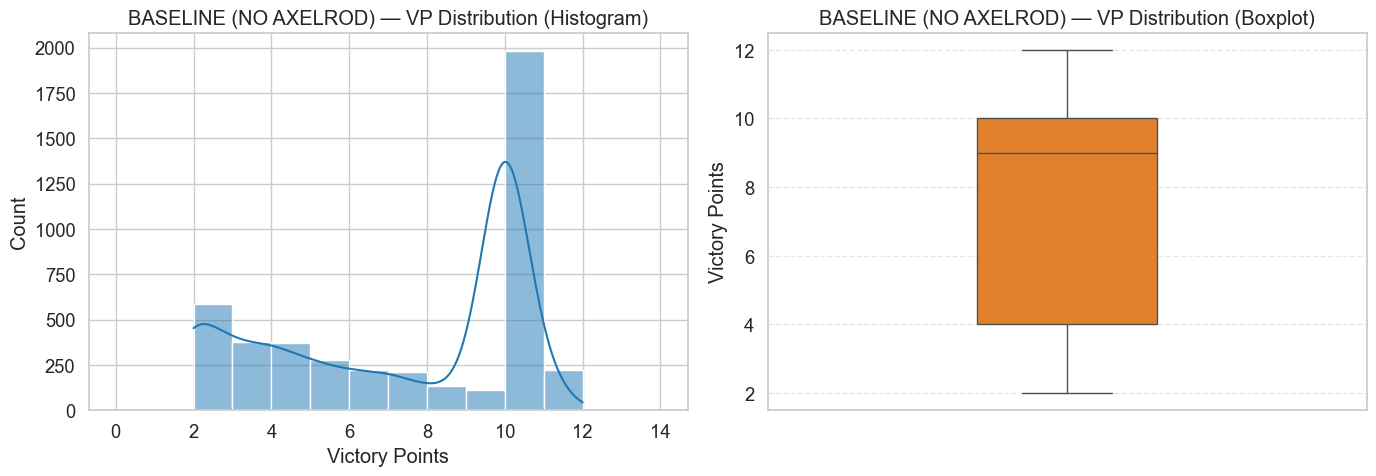

In [24]:
plot_bucket(buckets["baseline"], "baseline (no axelrod)")



=== BASELINE + AXELROD (N=500 games) ===
Win Rate: 50.6%
Avg VP  : 7.35


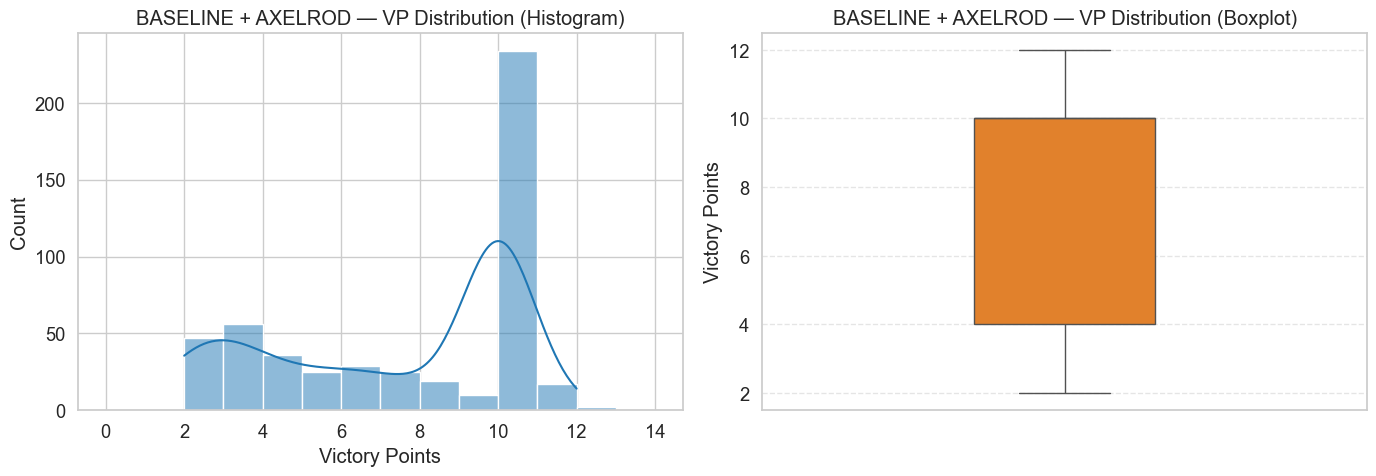

In [25]:
plot_bucket(buckets["baseline_axelrod"], "baseline + axelrod")



=== AWARE (NO AXELROD) (N=6000 games) ===
Win Rate: 49.5%
Avg VP  : 7.14


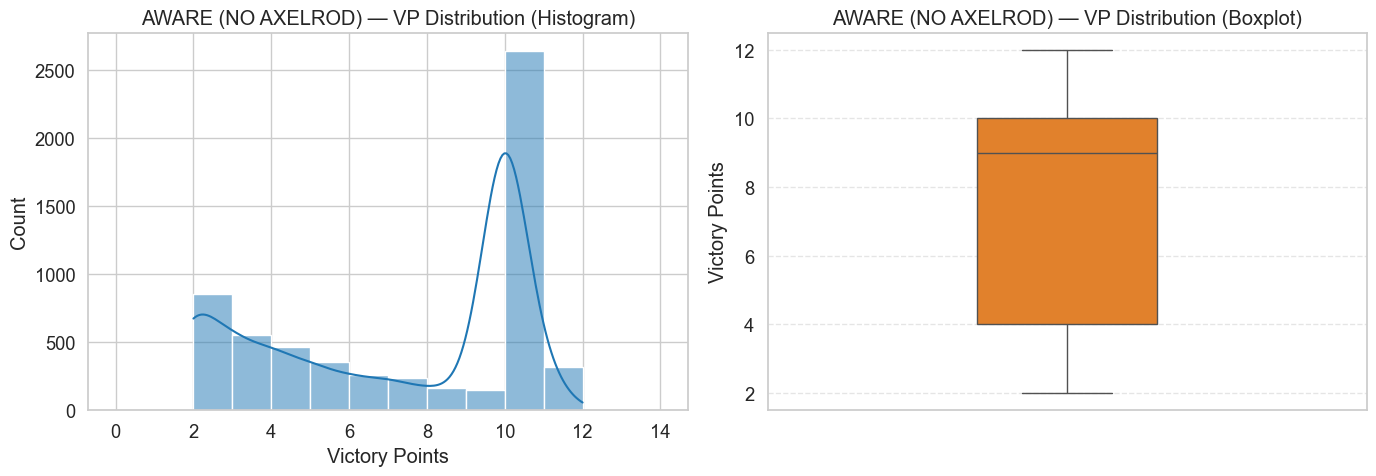

In [26]:
plot_bucket(buckets["aware"], "aware (no axelrod)")



=== AWARE + AXELROD (N=2500 games) ===
Win Rate: 47.6%
Avg VP  : 7.10


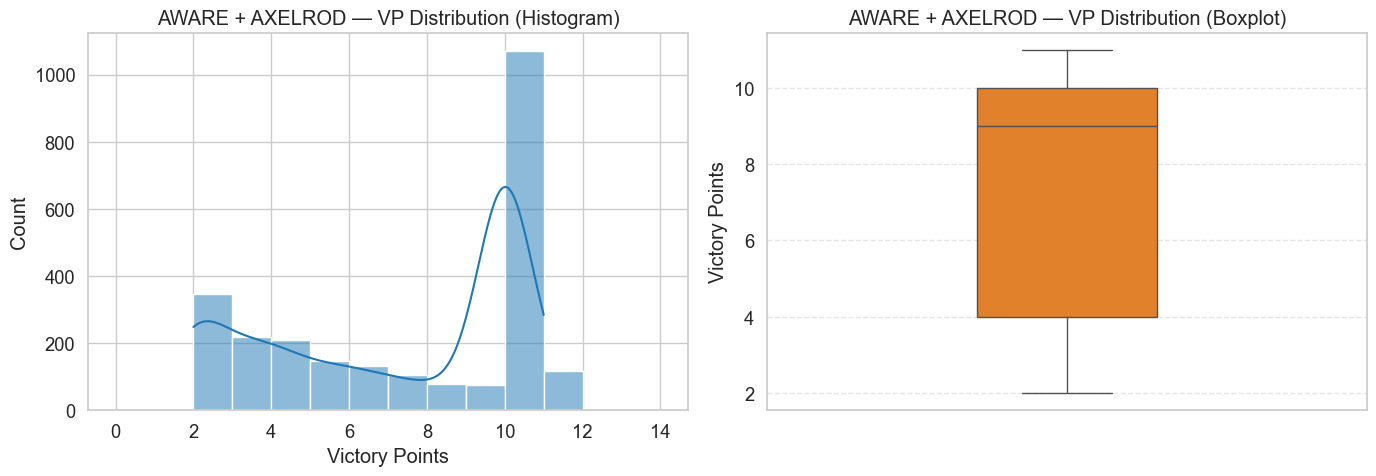

In [27]:
plot_bucket(buckets["aware_axelrod"], "aware + axelrod")



=== SHUFFLED (NO AXELROD) (N=2000 games) ===
Win Rate: 45.9%
Avg VP  : 6.93


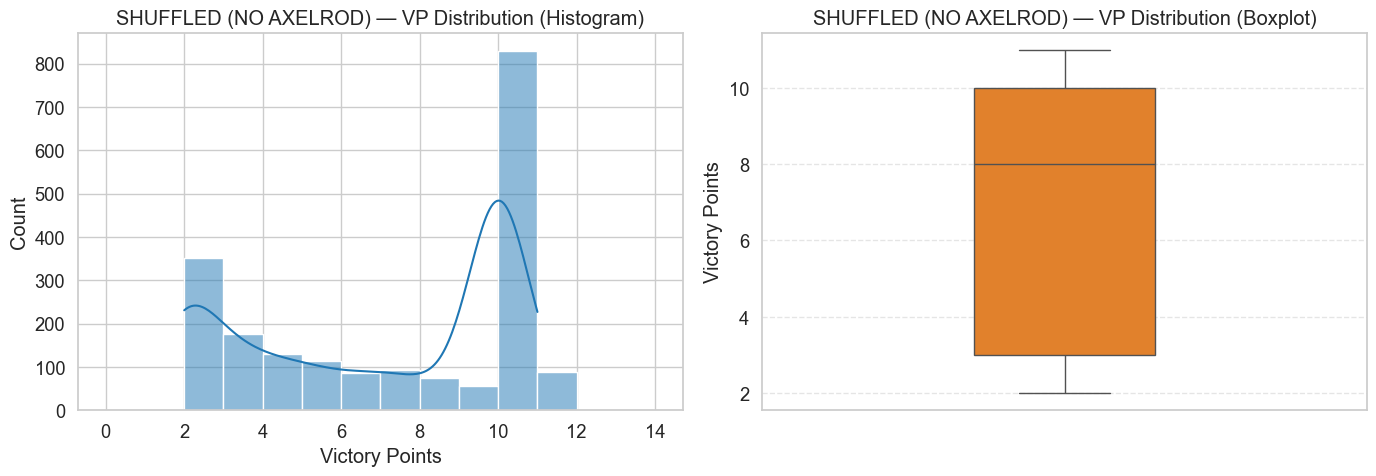

In [28]:
plot_bucket(buckets["shuffled"], "shuffled (no axelrod)")



=== SHUFFLED + AXELROD (N=1000 games) ===
Win Rate: 47.9%
Avg VP  : 7.35


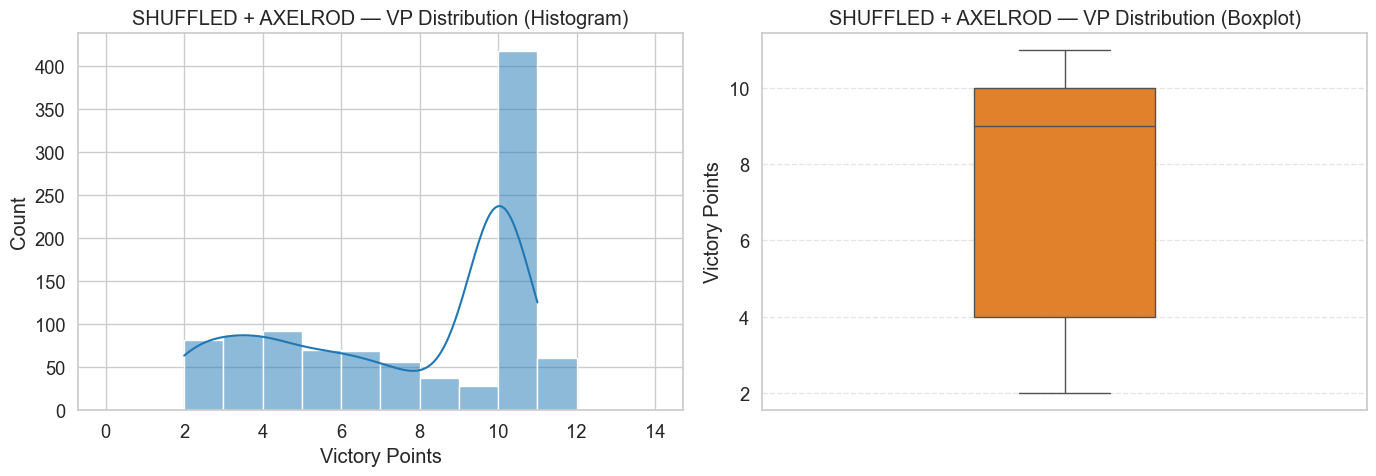

In [29]:
plot_bucket(buckets["shuffled_axelrod"], "shuffled + axelrod")


/var/folders/nt/67mjll3s4fb1vnp8mvn0q2kh0000gn/T/ipykernel_82132/1757483958.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="mode", y="vp", ax=axes[0], palette="viridis")
/var/folders/nt/67mjll3s4fb1vnp8mvn0q2kh0000gn/T/ipykernel_82132/1757483958.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=win_rates, x="mode", y="win_pct", ax=axes[1], palette="viridis")


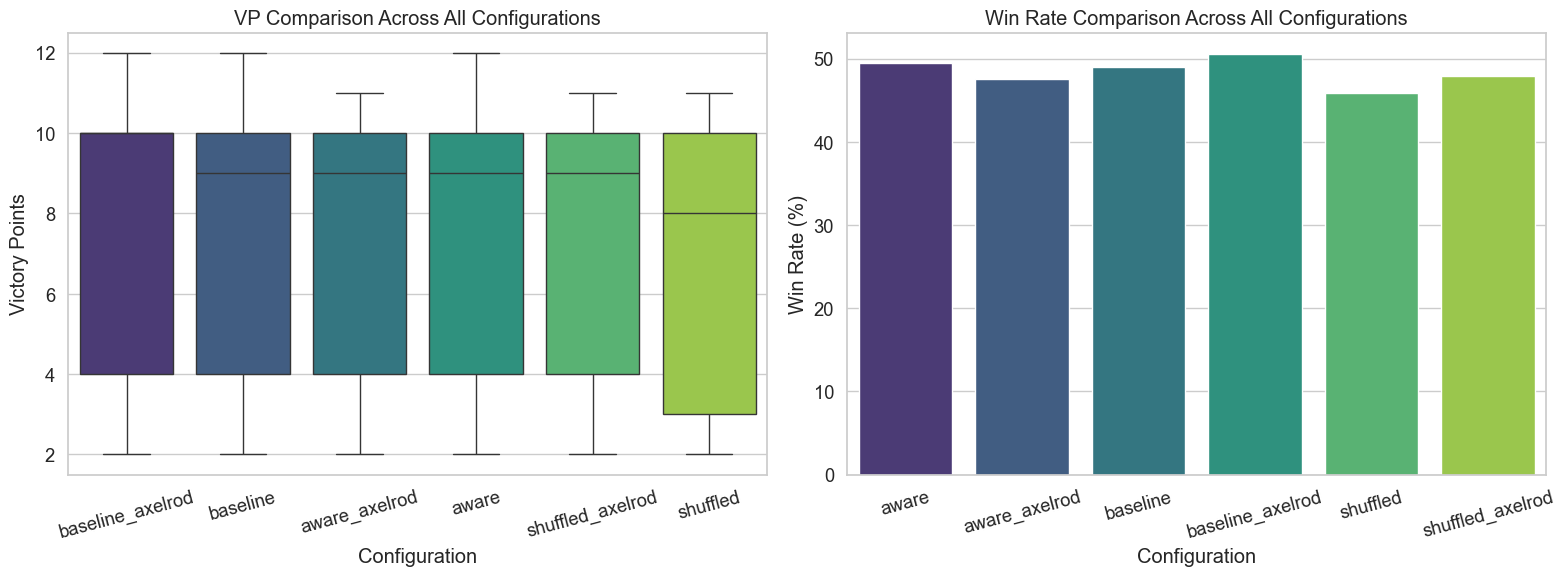

In [30]:
# Combined comparison plot
all_data = []
for label, files in buckets.items():
    if files:
        dfs = [pl.read_csv(str(f)) for f in files]
        df = pl.concat(dfs)
        combined = df.with_columns(pl.lit(label).alias("mode"))
        all_data.append(combined)

if all_data:
    full_df = pl.concat(all_data).to_pandas()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.boxplot(data=full_df, x="mode", y="vp", ax=axes[0], palette="viridis")
    axes[0].set_title("VP Comparison Across All Configurations")
    axes[0].set_xlabel("Configuration")
    axes[0].set_ylabel("Victory Points")
    axes[0].tick_params(axis="x", rotation=15)
    
    win_rates = full_df.groupby("mode")["won"].mean().reset_index()
    win_rates["win_pct"] = win_rates["won"] * 100
    sns.barplot(data=win_rates, x="mode", y="win_pct", ax=axes[1], palette="viridis")
    axes[1].set_title("Win Rate Comparison Across All Configurations")
    axes[1].set_xlabel("Configuration")
    axes[1].set_ylabel("Win Rate (%)")
    axes[1].tick_params(axis="x", rotation=15)
    
    plt.tight_layout()
    plt.show()
